In [61]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../..')

import blurtool

import torch
from PIL import Image

import matplotlib.pyplot as plt
import torchvision
import math
import random

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print('using:',blurtool.device)
device=blurtool.device
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.current_device())
print(torch.cuda.device(0))
print(torch.cuda.get_device_name(0))

using: cuda:0
True
1
0
NVIDIA GeForce GTX 1080


# Nonstationary blur modeling using robust eigenkernels

Abstract: 

### Example 0
figure showing LSV convolution, approximate LSV filter and PCA eigenkernel forward method.

In [63]:
# # test approx=False in nonstationary blur with a nondecomposed lattice (parallel forward)

# # resizer
# resize = torchvision.transforms.Resize(size=(256))

# # open test image
# test_image=Image.open('../../data/cameraman.tif').convert('L')
# test_image=torchvision.transforms.ToTensor()(test_image).squeeze()
# test_image=resize(test_image.unsqueeze(0)).squeeze()
# img_shape=test_image.shape
# print('img_shape=',img_shape)

# # define lattice
# kernel_shape=(32,32)
# lattice_pars={'ax':0.07,'ay':0.07,'bx':0.4,'by':0.3,'gamma_x':1,'gamma_y':1} # 0.07
# lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
# print('kernel_shape=',kernel_shape)

# # sample original lattice
# sampled_shape=(8,8)
# sampled_lat=lat.sample(sampled_shape)
# print('sampled_shape=',sampled_shape)
# r=15
# pars_pca={'r':r}
# pca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=pars_pca)

# # lsvc blur
# rgblur_lsvc=blurtool.NonstationaryBlur(lat,approx=False)
# blurred_test_image_lsvc=rgblur_lsvc.forward(test_image,n_pool=8,debug=True)
# print('computed lsvc blurred image')

# # approx filter blur
# rgblur=blurtool.NonstationaryBlur(lat)
# blurred_test_image=rgblur.forward(test_image,n_pool=8)
# print('computed approx filter blurred image')

# # pca lat blur 
# pca_blur=blurtool.NonstationaryBlur(pca_lat)
# blurred_test_image_pca=pca_blur.forward(test_image)
# print('computed pca lat blurred image')

# # # results
# fig,ax=plt.subplots(1,4,figsize=(15,15))

# ax[0].axis('off')
# ax[0].imshow(test_image,cmap='gray')
# ax[1].axis('off')
# ax[1].imshow(blurred_test_image_lsvc,cmap='gray')
# ax[2].axis('off')
# ax[2].imshow(blurred_test_image,cmap='gray')
# ax[3].axis('off')
# ax[3].imshow(blurred_test_image_pca,cmap='gray')
# plt.show()

# print('-------------------------------------------------------')
# print('forward_timer_lsvc=',rgblur_lsvc.forward_timer)
# print('forward_timer_approxfilter=',rgblur.forward_timer)
# print('forward_timer_pca=',pca_blur.forward_timer)
# print('-------------------------------------------------------')
# print('PSNR(blurred_lsvc,blurred_approxfilter)=',blurtool.psnr(blurred_test_image_lsvc,blurred_test_image))
# print('PSNR(blurred_approxfilter,blurred_pca)=',blurtool.psnr(blurred_test_image,blurred_test_image_pca))
# print('PSNR(blurred_lsvc,blurred_pca)=',blurtool.psnr(blurred_test_image_lsvc,blurred_test_image_pca))
# print('-------------------------------------------------------')
# print('SSIM(blurred_lsvc,blurred_approxfilter)=',blurtool.ssim(blurred_test_image_lsvc,blurred_test_image))
# print('SSIM(blurred_approxfilter,blurred_pca)=',blurtool.ssim(blurred_test_image,blurred_test_image_pca))
# print('SSIM(blurred_lsvc,blurred_pca)=',blurtool.ssim(blurred_test_image_lsvc,blurred_test_image_pca))

# # save images
# plt.imshow(test_image,cmap='gray')
# plt.axis('off')
# plt.savefig('ex0_x.eps',dpi=300, bbox_inches='tight',pad_inches=0)
# plt.show()

# plt.imshow(blurred_test_image_lsvc,cmap='gray')
# plt.axis('off')
# plt.savefig('ex0_y_lvsc.eps',dpi=300, bbox_inches='tight',pad_inches=0)
# plt.show()

# plt.imshow(blurred_test_image,cmap='gray')
# plt.axis('off')
# plt.savefig('ex0_y_approxfilter.eps',dpi=300, bbox_inches='tight',pad_inches=0)
# plt.show()

# plt.imshow(blurred_test_image_pca,cmap='gray')
# plt.axis('off')
# plt.savefig('ex0_y_pca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
# plt.show()

## Numerical experiments

### Example 1 (salt and pepper corrupted PSF)

In [64]:
# blurring a test image with a lattice of kernels versus the sampled-decomposed version of the same lattice

# set seed for reproducibility
# torch.manual_seed(0)

# resizer
resize = torchvision.transforms.Resize(size=(256))

# resize = torchvision.transforms.Resize(size=(512))

# open test image
test_image=Image.open('../../data/cameraman.tif').convert('L')
# test_image=Image.open('../../data/ccia/47.gif').convert('L')
test_image=torchvision.transforms.ToTensor()(test_image).squeeze().double()

# resize and normalize
test_image=resize(test_image.unsqueeze(0)).squeeze()
test_image=blurtool.normalize_minmax(test_image)
test_image=test_image.to(device)
img_shape=test_image.shape
print('img_shape=',img_shape)


# define lattice
kernel_shape=(32,32)
# lattice_pars={'ax':0.07,'ay':0.07,'bx':0.4,'by':0.3,'gamma_x':1,'gamma_y':1} # original exp0
lattice_pars={'ax':0.05,'ay':0.05,'bx':0.122,'by':0.1,'gamma_x':1,'gamma_y':1} # simpler exp0
# lattice_pars={'ax':0.06,'ay':0.06,'bx':0.2,'by':0.15,'gamma_x':1,'gamma_y':1} # half simpler exp0 (last one)

lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
print('kernel_shape=',kernel_shape)

# sample original lattice
sampled_shape=(8,8)
sampled_lat=lat.sample(sampled_shape)

# # find out the greatest salt and lowest pepper values
# salt_val=-10000
# pepper_val=10000
# for key in sampled_lat.kernels:
#     if torch.max(sampled_lat.kernels[key].psf_data)>salt_val:
#         salt_val=torch.max(sampled_lat.kernels[key].psf_data)
#     if torch.min(sampled_lat.kernels[key].psf_data)<pepper_val:
#         pepper_val=torch.min(sampled_lat.kernels[key].psf_data)

# use individual salt and pepper values
salt_val=None
pepper_val=None

# corrupt sampled kernels with salt and pepper noise
for key in sampled_lat.kernels:
    sampled_lat.kernels[key].psf_data=blurtool.spnoise(sampled_lat.kernels[key].psf_data,amount=0.03,salt_val=salt_val,pepper_val=pepper_val) # 0.1 # 0.2
     # amount was 0.1

img_shape= torch.Size([256, 256])
kernel_shape= (32, 32)


In [65]:
# find amplitude of maximum values
wlamb_unraveled=torch.zeros(sampled_shape)
max_sampled_kernels_unraveled=[]
for key in sampled_lat.kernels:
    #print(torch.round(torch.max(sampled_lat.kernels[key].psf_data),decimals=3).item())
    max_sampled_kernels_unraveled.append(torch.max(sampled_lat.kernels[key].psf_data).item())

amplitude_lamb=max(max_sampled_kernels_unraveled)
print(amplitude_lamb)

0.12803444941908232


In [66]:
# # sampled_shape=(8,8)
# # psf_pars={'sx':0.8,'sy':0.8}
# # wlamb_unraveled=blurtool.Kernel(sampled_shape,mode='gaussian',psf_pars=psf_pars)()
# # wlamb_unraveled=wlamb_unraveled-torch.min(wlamb_unraveled)
# # # wlamb_unraveled=0.03+2.8*wlamb_unraveled
# # wlamb_unraveled=0.015+4.5*wlamb_unraveled 
# # wlamb_unraveled=torch.round(wlamb_unraveled,decimals=3)

# # find amplitude of maximum values
# wlamb_unraveled=torch.zeros(sampled_shape)
# max_sampled_kernels_unraveled=[]
# for key in sampled_lat.kernels:
#     #print(torch.round(torch.max(sampled_lat.kernels[key].psf_data),decimals=3).item())
#     max_sampled_kernels_unraveled.append(torch.max(sampled_lat.kernels[key].psf_data).item())

# amplitude_lamb=max(max_sampled_kernels_unraveled)

# for key in sampled_lat.kernels:
# #     wlamb_unraveled[key[0],key[1]]=torch.max(sampled_lat.kernels[key].psf_data)+(0.13-amplitude_lamb)
# #     wlamb_unraveled[key[0],key[1]]=torch.round(wlamb_unraveled[key[0],key[1]],decimals=3)
#     wlamb_unraveled[key[0],key[1]]=0.035+0.06*torch.max(sampled_lat.kernels[key].psf_data)/amplitude_lamb
#     wlamb_unraveled[key[0],key[1]]=torch.round(wlamb_unraveled[key[0],key[1]],decimals=3)
    

# # visualize wlamb_unraveled
# fig, ax = plt.subplots()
# ax.imshow(wlamb_unraveled,cmap='gray')
# for i in range(sampled_shape[0]):
#     for j in range(sampled_shape[1]):
#         ax.text(j, i, str(wlamb_unraveled.clone().detach().numpy()[i, j]), color='r', ha='center', va='center')

        
# # write raveled wlamb
# wlamb=[None for i in range(sampled_shape[0]*sampled_shape[1])]
# for i in range(sampled_shape[0]):
#     for j in range(sampled_shape[1]):
#         raveled_pos=blurtool.ravel_multi_index((i,j),sampled_shape)
#         wlamb[raveled_pos]=wlamb_unraveled[i,j].item()
        
# print(wlamb)
        

mu= tensor(138.7250) . lamb= tensor([0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490,
        0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490,
        0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490,
        0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490,
        0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490,
        0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490,
        0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490,
        0.1490], dtype=torch.float64) . rank= 0
mu= tensor(138.7250) . lamb= tensor([0.1500, 0.1500, 0.1500, 0.1500, 0.1500, 0.1500, 0.1500, 0.1500, 0.1500,
        0.1500, 0.1500, 0.1500, 0.1500, 0.1500, 0.1500, 0.1500, 0.1500, 0.1500,
        0.1500, 0.1500, 0.1500, 0.1500, 0.1500, 0.1500, 0.1500, 0.1500, 0.1500,
        0.1500, 0.1500, 0.1500, 0.1500, 0.1500, 0.1500, 0.1500, 0.1500, 0.1500,
        0.1500

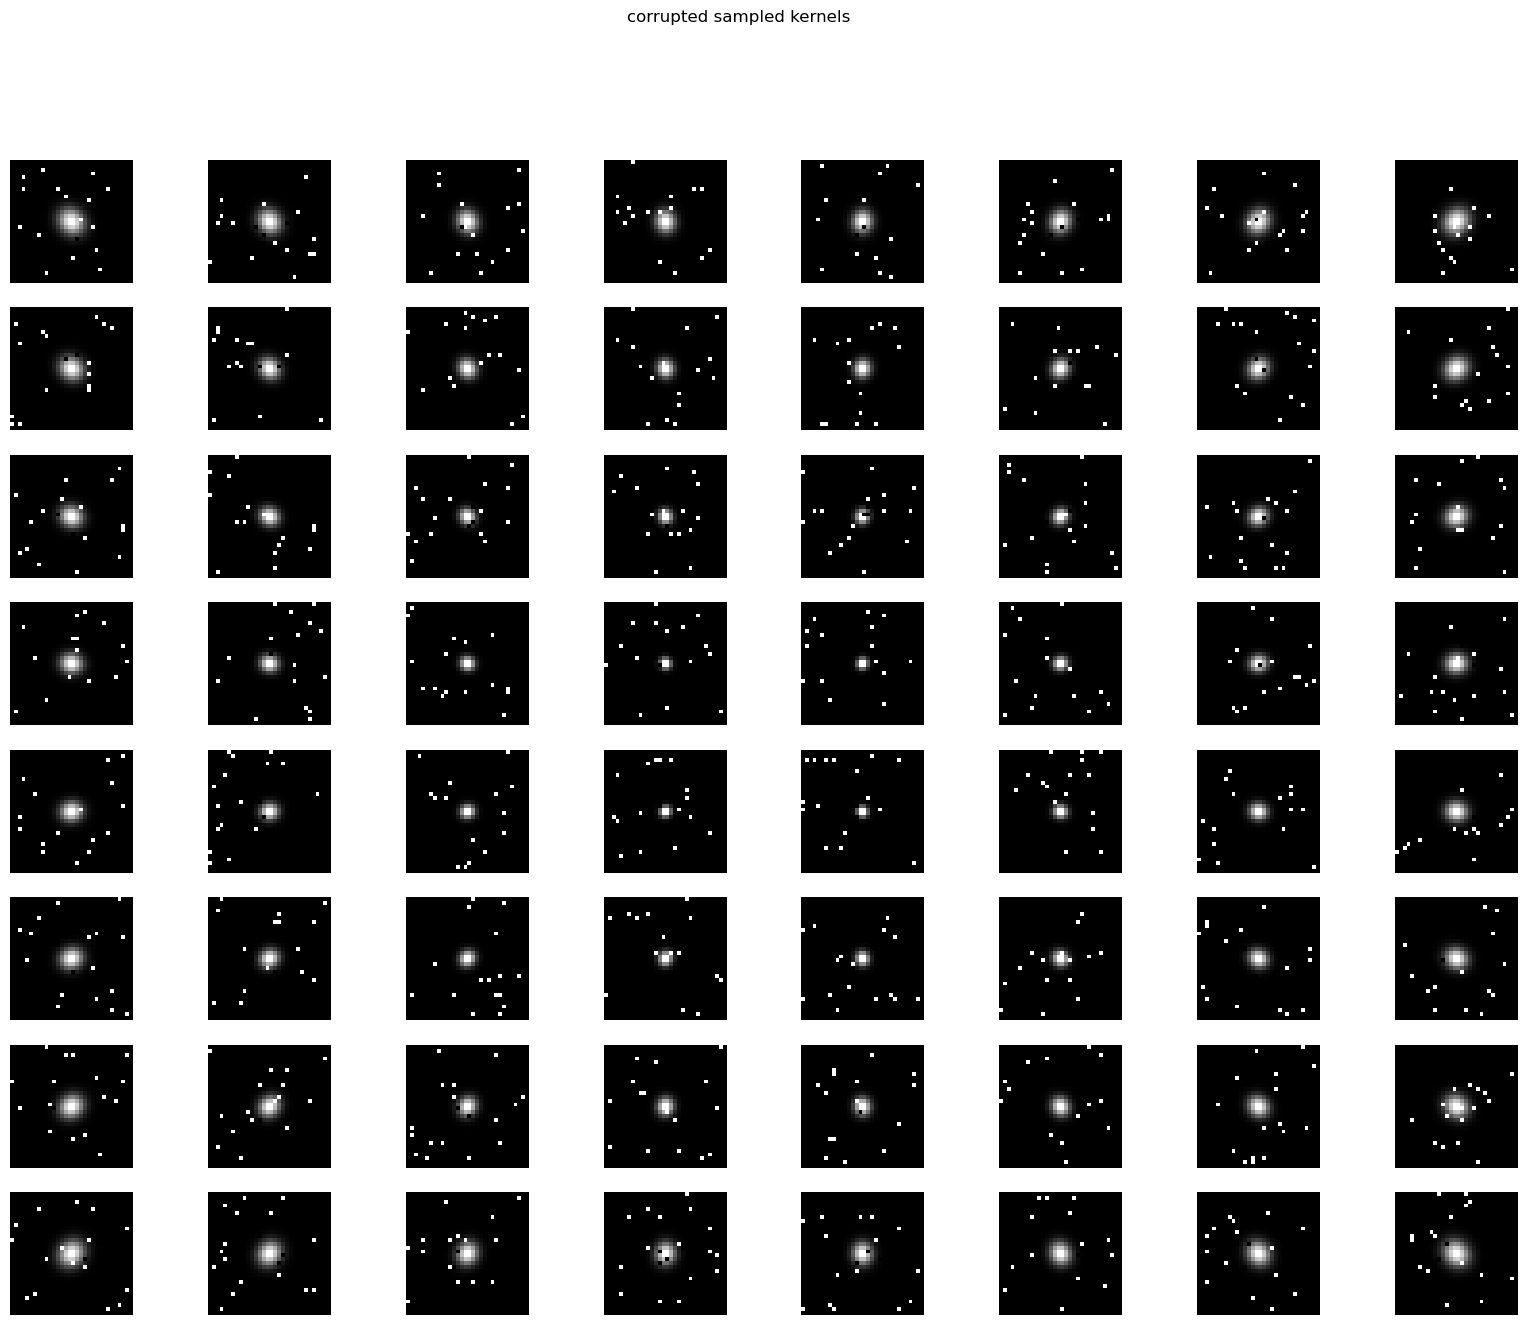

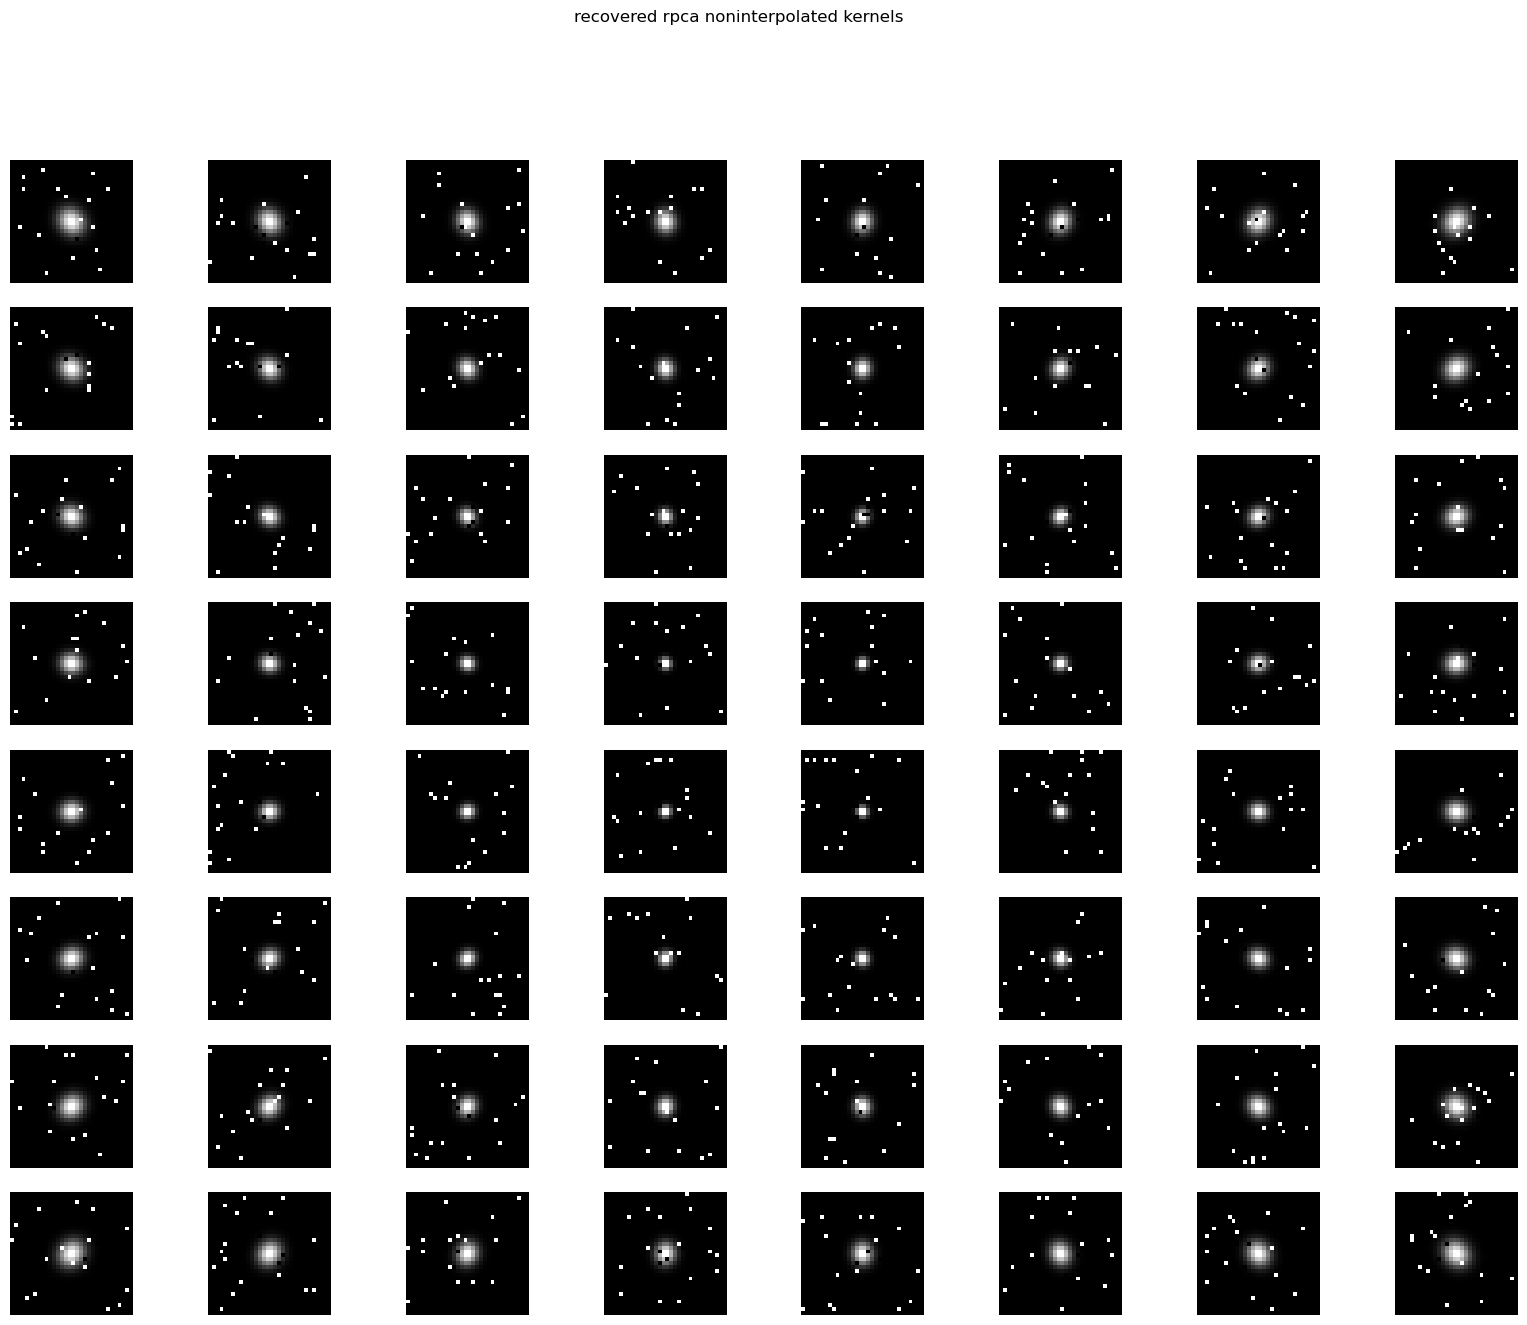

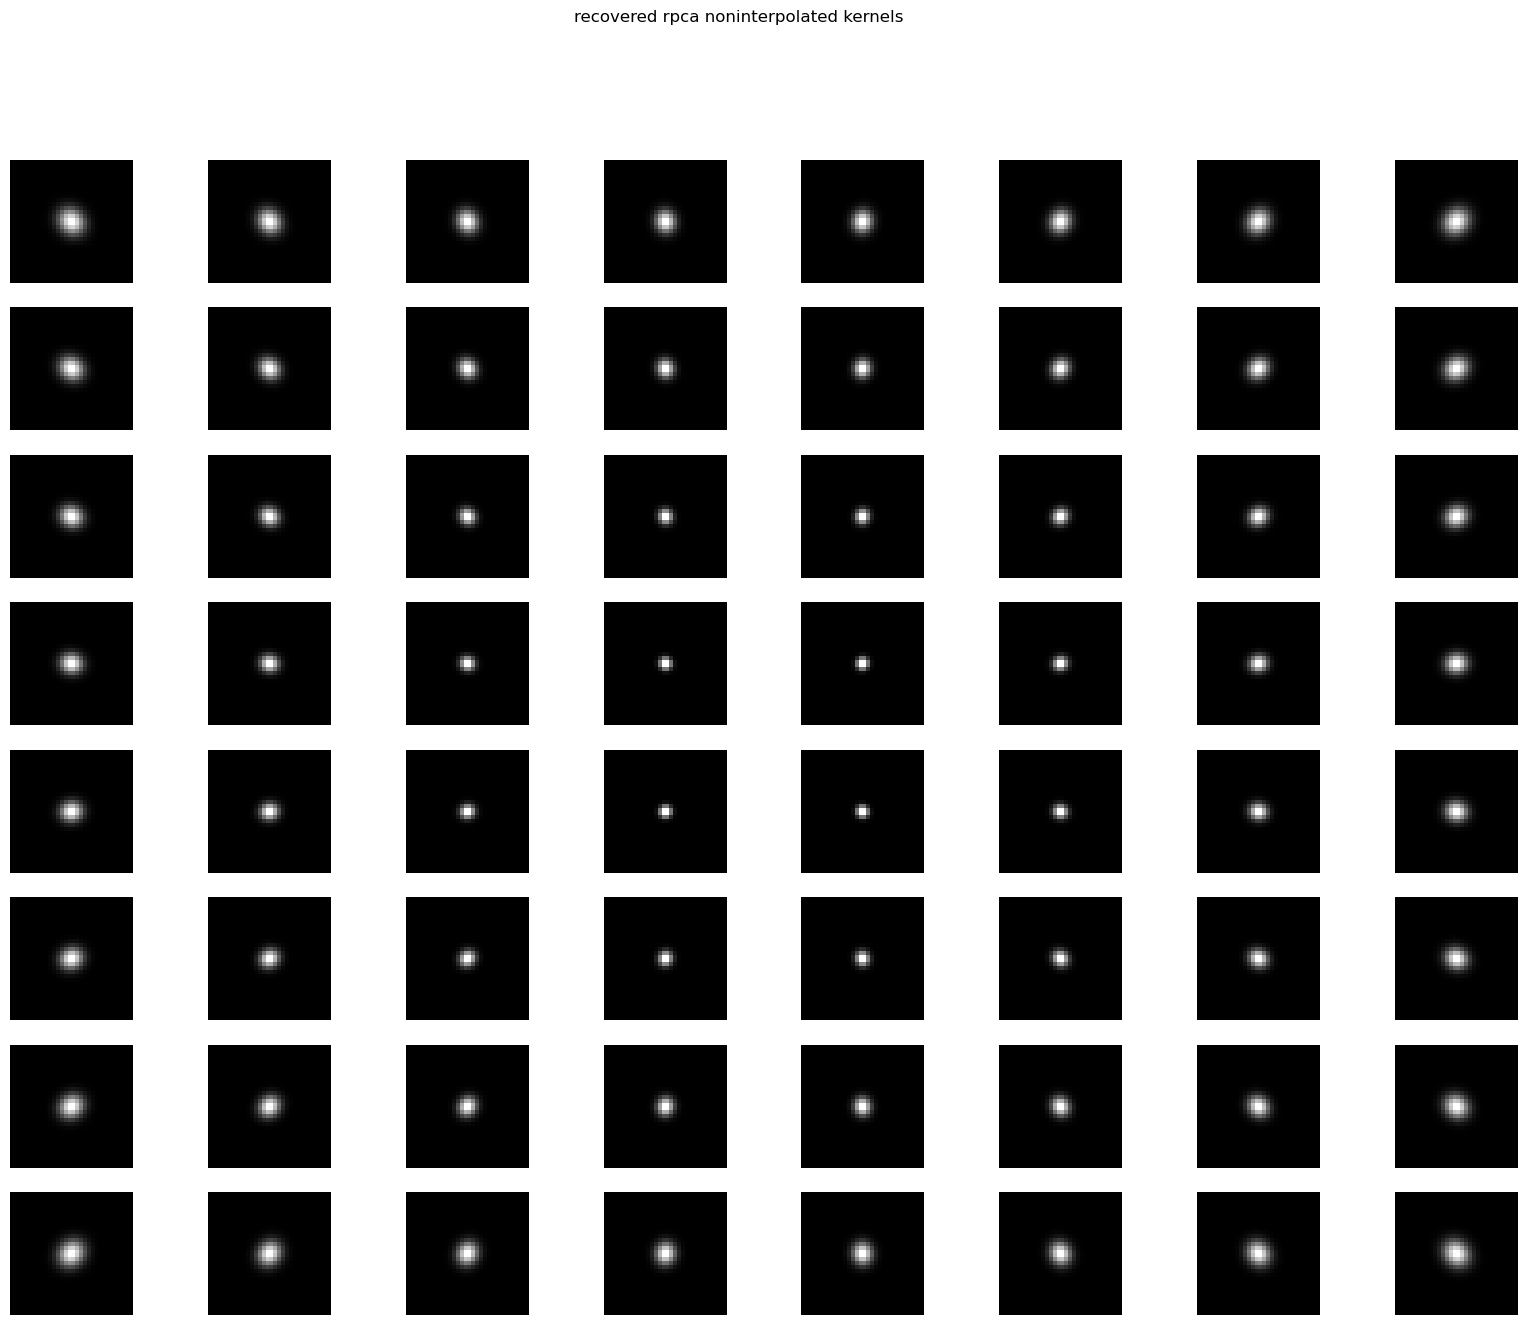

In [67]:
# decompose sampled lattice
r=64
pars_pca={'r':r}
pars_rpca={'lamb':0.149,'r':r,'tol':1e-20,'max_iter':500,'debug':False} # 0.08!!! or .09 for 0.1 of amount
# pars_rpca={'lamb':0.095,'r':r,'tol':1e-20,'max_iter':500,'debug':False} # last 


# pars_wrpca={'lamb':wlamb,'r':r,'tol':1e-20,'max_iter':500,'debug':False} 
pca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=pars_pca)
rpca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pcp_rpca',decompose_pars=pars_rpca)
# wrpca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pcp_rpca',decompose_pars=pars_wrpca)

r2=10
pars_pca2={'r':r2}
pars_rpca2={'lamb':0.15,'r':r2,'tol':1e-20,'max_iter':500,'debug':False} # 0.09 for 0.1 of amount
# pars_rpca2={'lamb':0.095,'r':r2,'tol':1e-20,'max_iter':500,'debug':False} # 0.09 for 0.1 of amount last

# pars_wrpca2={'lamb':wlamb,'r':r2,'tol':1e-20,'max_iter':500,'debug':False} 
pca2_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=pars_pca2)
rpca2_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pcp_rpca',decompose_pars=pars_rpca2)
# wrpca2_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pcp_rpca',decompose_pars=pars_wrpca2)



# plot corrupted sampled kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('corrupted sampled kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(sampled_lat.kernel([i,j])().cpu(),cmap='gray')
plt.show()


# plot reconsctructed pca noninterpolated kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('recovered rpca noninterpolated kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat.noninterpolated_kernel([i,j])().cpu(),cmap='gray')
plt.show()

# plot reconsctructed rpca noninterpolated kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('recovered rpca noninterpolated kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(rpca_lat.noninterpolated_kernel([i,j])().cpu(),cmap='gray')
plt.show()

# # plot reconsctructed rpca noninterpolated kernels
# fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
# fig.suptitle('recovered wrpca noninterpolated kernels')
# for i in range(sampled_shape[0]):
#     for j in range(sampled_shape[1]):
#         ax[i,j].axis('off')
#         ax[i,j].imshow(wrpca_lat.noninterpolated_kernel([i,j])().cpu(),cmap='gray')
# plt.show()

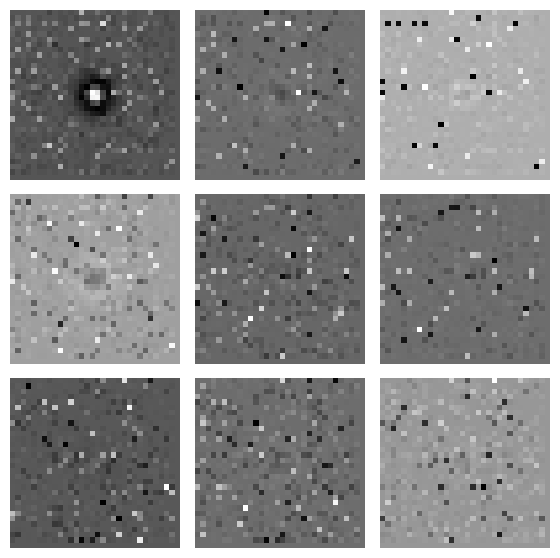

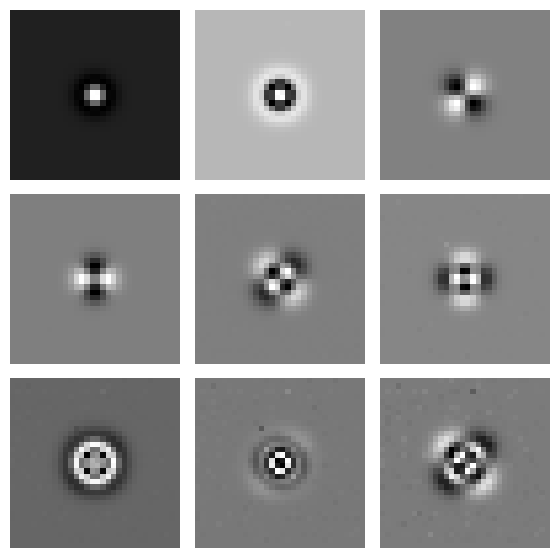

In [68]:
# plot pca kernels
n_rows=3
n_columns=3
fig,ax=plt.subplots(n_rows,n_columns,figsize=(5.7,6))
fig.tight_layout(pad=1, h_pad=0, w_pad=0)
# fig.suptitle('pca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat.eigenkernels[int(1+i*n_rows+j)]().cpu(),cmap='gray')
plt.tight_layout()
plt.savefig('res0_pca_9eigenkernels.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

# plot rpca kernels
n_rows=3
n_columns=3
fig,ax=plt.subplots(n_rows,n_columns,figsize=(5.7,6))
fig.tight_layout(pad=1, h_pad=0, w_pad=0)
# fig.suptitle('rpca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(rpca_lat.eigenkernels[int(1+i*n_rows+j)]().cpu(),cmap='gray')
plt.tight_layout()
plt.savefig('res0_rpca_9eigenkernels.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

# # plot wrpca kernels
# n_rows=3
# n_columns=3
# fig,ax=plt.subplots(n_rows,n_columns,figsize=(5.7,6))
# fig.tight_layout(pad=1, h_pad=0, w_pad=0)
# # fig.suptitle('rpca eigenkernels')
# for i in range(n_rows):
#     for j in range(n_columns):
#         ax[i,j].axis('off')
#         ax[i,j].imshow(wrpca_lat.eigenkernels[int(1+i*n_rows+j)]().cpu(),cmap='gray')
# plt.tight_layout()
# plt.savefig('res0_wrpca_9eigenkernels.eps',dpi=300, bbox_inches='tight',pad_inches=0)
# plt.show()

### scree plots

In [69]:
# plt.plot(rpca_lat.singularvalues[1:],label=r'robust eigenkernels (constant $\lambda$)')
# plt.plot(wrpca_lat.singularvalues[1:],label=r'robust eigenkernels (variable $\lambda$)')
# plt.plot(pca_lat.singularvalues[1:],label='standard eigenkernels')
# plt.ylabel(r'$k$-th singular value')
# plt.xlabel(r'$k$',fontsize=12)
# plt.legend(fontsize=11)
# plt.xticks(fontsize=11)
# plt.yticks(fontsize=11)
# plt.legend();
# plt.savefig('res0_singular_values_w.eps',dpi=300, bbox_inches='tight',pad_inches=0)
# plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


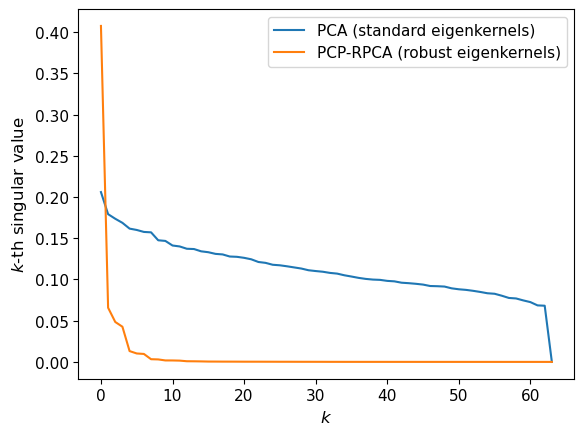

In [70]:
plt.plot(pca_lat.singularvalues[1:],label='PCA (standard eigenkernels)')
plt.plot(rpca_lat.singularvalues[1:],label=r'PCP-RPCA (robust eigenkernels)')
plt.ylabel(r'$k$-th singular value',fontsize=12)
plt.xlabel(r'$k$',fontsize=12)
plt.legend(fontsize=11)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.savefig('res0_singular_values.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

In [71]:
# suggested lambda value 
1/math.sqrt(kernel_shape[0]*kernel_shape[1])

0.03125

In [72]:
# mean PSNR and SSIM

psnr_pca=[]
psnr_rpca=[]
psnr_wrpca=[]
ssim_pca=[]
ssim_rpca=[]
ssim_wrpca=[]

psnr_pca2=[]
psnr_rpca2=[]
psnr_wrpca2=[]
ssim_pca2=[]
ssim_rpca2=[]
ssim_wrpca2=[]


resampled_lat=lat.sample(sampled_shape)

for key in sampled_lat.kernels:
    psnr_pca.append(blurtool.psnr(resampled_lat.kernel(key)(),pca_lat.noninterpolated_kernel(key)()).item())
    psnr_rpca.append(blurtool.psnr(resampled_lat.kernel(key)(),rpca_lat.noninterpolated_kernel(key)()).item())    
#     psnr_wrpca.append(blurtool.psnr(resampled_lat.kernel(key)(),wrpca_lat.noninterpolated_kernel(key)()).item())
    ssim_pca.append(blurtool.ssim(resampled_lat.kernel(key)(),pca_lat.noninterpolated_kernel(key)()).item())
    ssim_rpca.append(blurtool.ssim(resampled_lat.kernel(key)(),rpca_lat.noninterpolated_kernel(key)()).item())
#     ssim_wrpca.append(blurtool.ssim(resampled_lat.kernel(key)(),wrpca_lat.noninterpolated_kernel(key)()).item())
        
    psnr_pca2.append(blurtool.psnr(resampled_lat.kernel(key)(),pca2_lat.noninterpolated_kernel(key)()).item())
    psnr_rpca2.append(blurtool.psnr(resampled_lat.kernel(key)(),rpca2_lat.noninterpolated_kernel(key)()).item())    
#     psnr_wrpca2.append(blurtool.psnr(resampled_lat.kernel(key)(),wrpca2_lat.noninterpolated_kernel(key)()).item())
    ssim_pca2.append(blurtool.ssim(resampled_lat.kernel(key)(),pca2_lat.noninterpolated_kernel(key)()).item())
    ssim_rpca2.append(blurtool.ssim(resampled_lat.kernel(key)(),rpca2_lat.noninterpolated_kernel(key)()).item())
#     ssim_wrpca2.append(blurtool.ssim(resampled_lat.kernel(key)(),wrpca2_lat.noninterpolated_kernel(key)()).item())
    
print('-----------------------------')
print('mean PSNR(psf,psf_pca)=',sum(psnr_pca)/len(psnr_pca))
print('mean SSIM(psf,psf_pca)=',sum(ssim_pca)/len(ssim_pca))
print('-----------------------------')
print('mean PSNR(psf,psf_rpca)=',sum(psnr_rpca)/len(psnr_rpca))
print('mean SSIM(psf,psf_rpca)=',sum(ssim_rpca)/len(ssim_rpca))
print('-----------------------------')
# print('mean PSNR(psf,psf_wrpca)=',sum(psnr_wrpca)/len(psnr_wrpca))
# print('mean SSIM(psf,psf_wrpca)=',sum(ssim_wrpca)/len(ssim_wrpca))
print('-----------------------------')
print('mean PSNR(psf,psf_pca2)=',sum(psnr_pca2)/len(psnr_pca2))
print('mean SSIM(psf,psf_pca2)=',sum(ssim_pca2)/len(ssim_pca2))
print('-----------------------------')
print('mean PSNR(psf,psf_rpca2)=',sum(psnr_rpca2)/len(psnr_rpca2))
print('mean SSIM(psf,psf_rpca2)=',sum(ssim_rpca2)/len(ssim_rpca2))
print('-----------------------------')
# print('mean PSNR(psf,psf_wrpca2)=',sum(psnr_wrpca2)/len(psnr_wrpca2))
# print('mean SSIM(psf,psf_wrpca2)=',sum(ssim_wrpca2)/len(ssim_wrpca2))

-----------------------------
mean PSNR(psf,psf_pca)= 18.29992998318877
mean SSIM(psf,psf_pca)= 0.988644624075306
-----------------------------
mean PSNR(psf,psf_rpca)= 80.68455390254482
mean SSIM(psf,psf_rpca)= 0.999981505723861
-----------------------------
-----------------------------
mean PSNR(psf,psf_pca2)= 19.88958682960866
mean SSIM(psf,psf_pca2)= 0.9915802591904722
-----------------------------
mean PSNR(psf,psf_rpca2)= 66.73882835375157
mean SSIM(psf,psf_rpca2)= 0.9999818032818599
-----------------------------


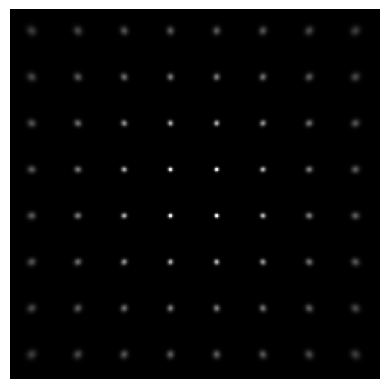

In [73]:
plt.imshow(lat.grid((8,8),blur=True,normalize=False).cpu(),cmap='gray')
plt.axis('off')
plt.savefig('res0_h.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

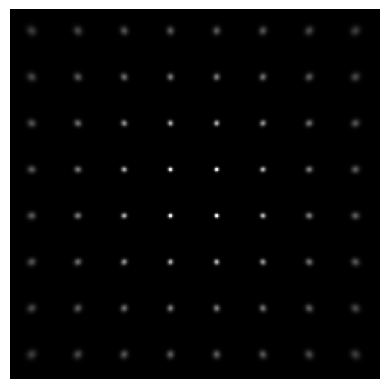

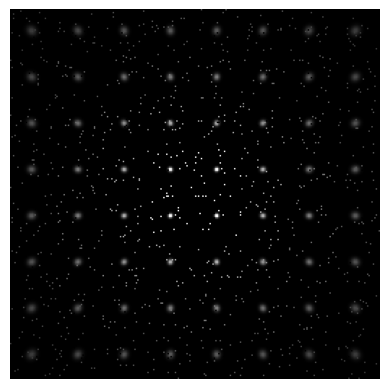

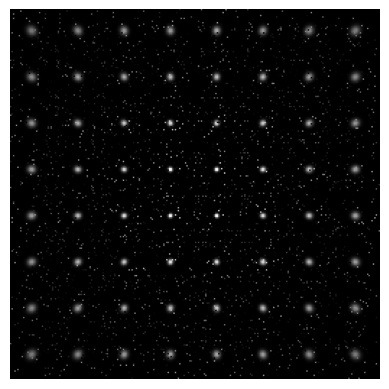

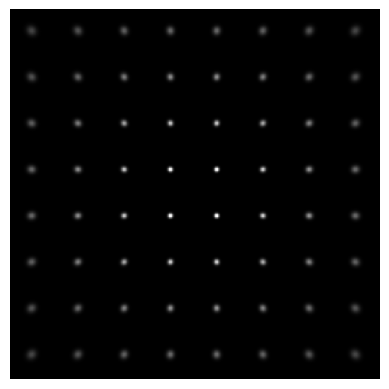

In [74]:
normalize=False

plt.imshow(lat.grid((8,8),blur=True,normalize=normalize).cpu(),cmap='gray')
plt.axis('off')
plt.savefig('res0_h.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()


resampled_lat=sampled_lat.sample(sampled_shape,normalize=normalize,normalize_mode='minmax')
view_sampled_lat=blurtool.InterpolateLattice(resampled_lat,img_shape,mode='zero_dummy')
plt.imshow(view_sampled_lat.grid(sampled_shape,blur=True).cpu(),cmap='gray')
plt.axis('off')
plt.savefig('res0_hplusnoise.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()




plt.imshow(pca_lat.grid((8,8),blur=True,normalize=normalize).cpu(),cmap='gray')
plt.axis('off')
plt.savefig('res0_hhat_pca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

# plt.imshow(pca2_lat.grid((8,8),blur=True,normalize=normalize).cpu(),cmap='gray')
# plt.axis('off')
# plt.savefig('res0_hhat_pca2.eps',dpi=300, bbox_inches='tight',pad_inches=0)
# plt.show()


plt.imshow(rpca_lat.grid((8,8),blur=True,normalize=normalize).cpu(),cmap='gray')
plt.axis('off')
plt.savefig('res0_hhat_rpca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

# plt.imshow(rpca_lat.grid((8,8),blur=True,normalize=normalize).cpu(),cmap='gray')
# plt.axis('off')
# plt.savefig('res0_hhat_rpca2.eps',dpi=300, bbox_inches='tight',pad_inches=0)
# plt.show()

In [75]:
# plt.imshow(wrpca_lat.grid((8,8),blur=True,normalize=True).cpu(),cmap='gray')
# plt.axis('off')
# plt.savefig('res0_hhat_wrpca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
# plt.show()

# plt.imshow(wrpca_lat.grid((8,8),blur=True,normalize=True).cpu(),cmap='gray')
# plt.axis('off')
# plt.savefig('res0_hhat_wrpca2.eps',dpi=300, bbox_inches='tight',pad_inches=0)
# plt.show()

finished row  0
finished row  1
finished row  2
finished row  3
finished row  4
finished row  5
finished row  6
finished row  7
finished row  8
finished row  9
finished row  10
finished row  11
finished row  12
finished row  13
finished row  14
finished row  15
finished row  16
finished row  17
finished row  18
finished row  19
finished row  20
finished row  21
finished row  22
finished row  23
finished row  24
finished row  25
finished row  26
finished row  27
finished row  28
finished row  29
finished row  30
finished row  31
finished row  32
finished row  33
finished row  34
finished row  35
finished row  36
finished row  37
finished row  38
finished row  39
finished row  40
finished row  41
finished row  42
finished row  43
finished row  44
finished row  45
finished row  46
finished row  47
finished row  48
finished row  49
finished row  50
finished row  51
finished row  52
finished row  53
finished row  54
finished row  55
finished row  56
finished row  57
finished row  58
finishe

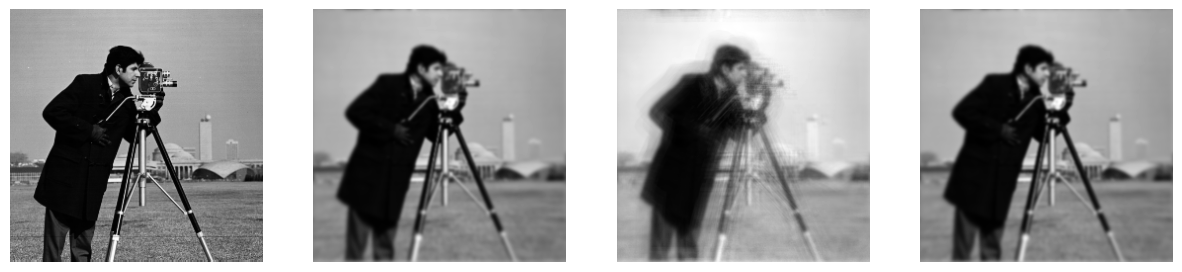

blur.forward_timer= 42.95887422305532
pca_blur.forward_timer= 0.14068332081660628
rpca_blur.forward_timer= 0.1390838271472603
PSNR(blurred,pca_blurred)= tensor(15.9966, device='cuda:0', dtype=torch.float64)
PSNR(blurred,rpca_blurred)= tensor(48.7731, device='cuda:0', dtype=torch.float64)
PSNR(blurred,rpca2_blurred)= tensor(48.7565, device='cuda:0', dtype=torch.float64)
SSIM(blurred,pca_blurred)= tensor(0.8975, dtype=torch.float64)
SSIM(blurred,rpca_blurred)= tensor(0.9997, dtype=torch.float64)
SSIM(blurred,rpca2_blurred)= tensor(0.9997, dtype=torch.float64)


In [76]:
## blur a test image 

# define blurs and apply
blur=blurtool.NonstationaryBlur(lat)
pca_blur=blurtool.NonstationaryBlur(pca_lat)
rpca_blur=blurtool.NonstationaryBlur(rpca_lat)
rpca2_blur=blurtool.NonstationaryBlur(rpca2_lat)
# wrpca_blur=blurtool.NonstationaryBlur(wrpca_lat)

blurred_test_image=blur.forward(test_image,n_pool=8,debug=True)
pca_blurred_test_image=pca_blur.forward(test_image,debug=False)
rpca_blurred_test_image=rpca_blur.forward(test_image,debug=False)
rpca2_blurred_test_image=rpca2_blur.forward(test_image,debug=False)
# wrpca_blurred_test_image=wrpca_blur.forward(test_image,debug=False)


fig,ax=plt.subplots(1,4,figsize=(15,15))

ax[0].axis('off')
ax[0].imshow(test_image.cpu(),cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image.cpu(),cmap='gray')
ax[2].axis('off')
ax[2].imshow(pca_blurred_test_image.cpu(),cmap='gray')
ax[3].axis('off')
ax[3].imshow(rpca_blurred_test_image.cpu(),cmap='gray')
# ax[3].axis('off')
# ax[3].imshow(wrpca_blurred_test_image.cpu(),cmap='gray')
plt.show()

# print forward timers
print('blur.forward_timer=',blur.forward_timer)
print('pca_blur.forward_timer=',pca_blur.forward_timer)
print('rpca_blur.forward_timer=',rpca_blur.forward_timer)
# print('wrpca_blur.forward_timer=',wrpca_blur.forward_timer)

# print psnr
print('PSNR(blurred,pca_blurred)=',blurtool.psnr(blurred_test_image,pca_blurred_test_image))
print('PSNR(blurred,rpca_blurred)=',blurtool.psnr(blurred_test_image,rpca_blurred_test_image))
print('PSNR(blurred,rpca2_blurred)=',blurtool.psnr(blurred_test_image,rpca2_blurred_test_image))
# print('PSNR(blurred,wrpca_blurred)=',blurtool.psnr(blurred_test_image,wrpca_blurred_test_image))

print('SSIM(blurred,pca_blurred)=',blurtool.ssim(blurred_test_image,pca_blurred_test_image))
print('SSIM(blurred,rpca_blurred)=',blurtool.ssim(blurred_test_image,rpca_blurred_test_image))
print('SSIM(blurred,rpca2_blurred)=',blurtool.ssim(blurred_test_image,rpca2_blurred_test_image))
# print('SSIM(blurred,wrpca_blurred)=',blurtool.ssim(blurred_test_image,wrpca_blurred_test_image))


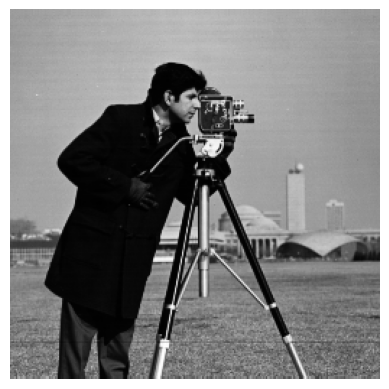

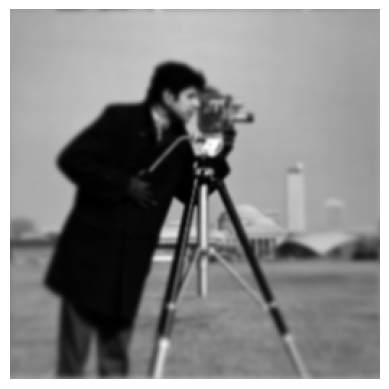

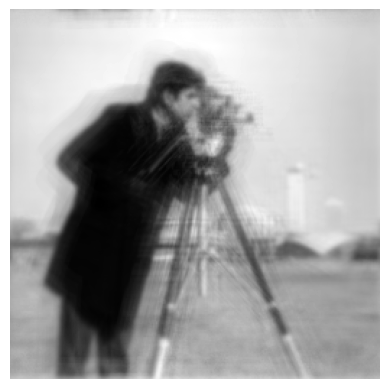

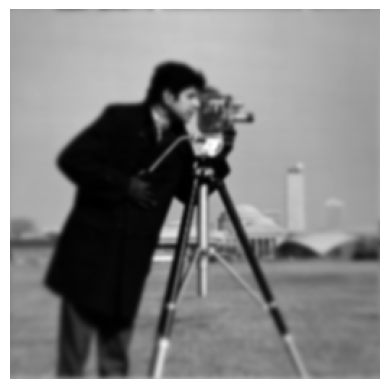

In [77]:
# save images
plt.imshow(test_image.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('res0_x.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(blurred_test_image.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('res0_y.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(pca_blurred_test_image.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('res0_ypca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(rpca_blurred_test_image.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('res0_yrpca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

# plt.imshow(wrpca_blurred_test_image.cpu(),cmap='gray')
# plt.axis('off')
# plt.savefig('res0_ywrpca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
# plt.show()

In [28]:
# # resizer
# resize = torchvision.transforms.Resize(size=(256))

# # open test image
# test_image=Image.open('../../data/cameraman.tif').convert('L')
# # test_image=Image.open('../../data/ccia/47.gif').convert('L')
# test_image=torchvision.transforms.ToTensor()(test_image).squeeze().double()

# # resize and normalize
# test_image=resize(test_image.unsqueeze(0)).squeeze()
# test_image=blurtool.normalize_minmax(test_image)
# test_image=test_image.to(device)
# img_shape=test_image.shape
# print('img_shape=',img_shape)

In [29]:
# 300 iterations time comparison
# print(deblur_pca.forward_timer) cpu=100.17550982203102
# print(deblur_pca.forward_timer) gpu=86.94886548898648

In [78]:
# sample original lattice
resampled_lat_gt=lat.sample(sampled_shape)


r=64
pars_gt_pca={'r':r}
lat_gt=blurtool.DecomposeLattice(resampled_lat_gt,img_shape,mode='pca',decompose_pars=pars_pca)
blur_gt=blurtool.NonstationaryBlur(lat_gt)

blurred_test_image_gt=blur_gt.forward(test_image)

sub iteration:  0 	 rj_energy= 29.172535518992685
iter:  0 	 PSNR= 21.076880924730443
sub iteration:  1 	 rj_energy= 4.145867102201801
iter:  1 	 PSNR= 22.242086067169268
sub iteration:  2 	 rj_energy= 1.14514756717876
iter:  2 	 PSNR= 23.145643219562835
sub iteration:  3 	 rj_energy= 0.45346686721958285
iter:  3 	 PSNR= 22.999910402001497
sub iteration:  4 	 rj_energy= 0.2078741554349953
iter:  4 	 PSNR= 22.876794369443036
sub iteration:  5 	 rj_energy= 0.11144223934404743
iter:  5 	 PSNR= 22.984319404526
sub iteration:  6 	 rj_energy= 0.06869947379565057
iter:  6 	 PSNR= 22.896558863878205
sub iteration:  7 	 rj_energy= 0.04447415597998359
iter:  7 	 PSNR= 22.960930894656478
sub iteration:  8 	 rj_energy= 0.029959282875816336
iter:  8 	 PSNR= 22.992611816515378
sub iteration:  9 	 rj_energy= 0.01990497190458618
iter:  9 	 PSNR= 22.985289451617746
sub iteration:  10 	 rj_energy= 0.014593043334904332
iter:  10 	 PSNR= 23.023357303659502
sub iteration:  11 	 rj_energy= 0.011023003083053

sub iteration:  91 	 rj_energy= 1.0008739705475005e-05
iter:  91 	 PSNR= 24.071891265194687
sub iteration:  92 	 rj_energy= 9.411781273433335e-06
iter:  92 	 PSNR= 24.075126001908313
sub iteration:  93 	 rj_energy= 8.991259699027805e-06
iter:  93 	 PSNR= 24.079993200505893
sub iteration:  94 	 rj_energy= 8.554979066765444e-06
iter:  94 	 PSNR= 24.085841341130717
sub iteration:  95 	 rj_energy= 8.15077382860648e-06
iter:  95 	 PSNR= 24.093557975671388
sub iteration:  96 	 rj_energy= 7.918673961977526e-06
iter:  96 	 PSNR= 24.10384906159365
sub iteration:  97 	 rj_energy= 7.57429741437011e-06
iter:  97 	 PSNR= 24.114788989067208
sub iteration:  98 	 rj_energy= 7.396973213651181e-06
iter:  98 	 PSNR= 24.125639191762843
sub iteration:  99 	 rj_energy= 7.105189563935902e-06
iter:  99 	 PSNR= 24.13741660893402
sub iteration:  100 	 rj_energy= 7.1360997193853006e-06
iter:  100 	 PSNR= 24.148924881414967
sub iteration:  101 	 rj_energy= 6.5358944484936505e-06
iter:  101 	 PSNR= 24.161800731471

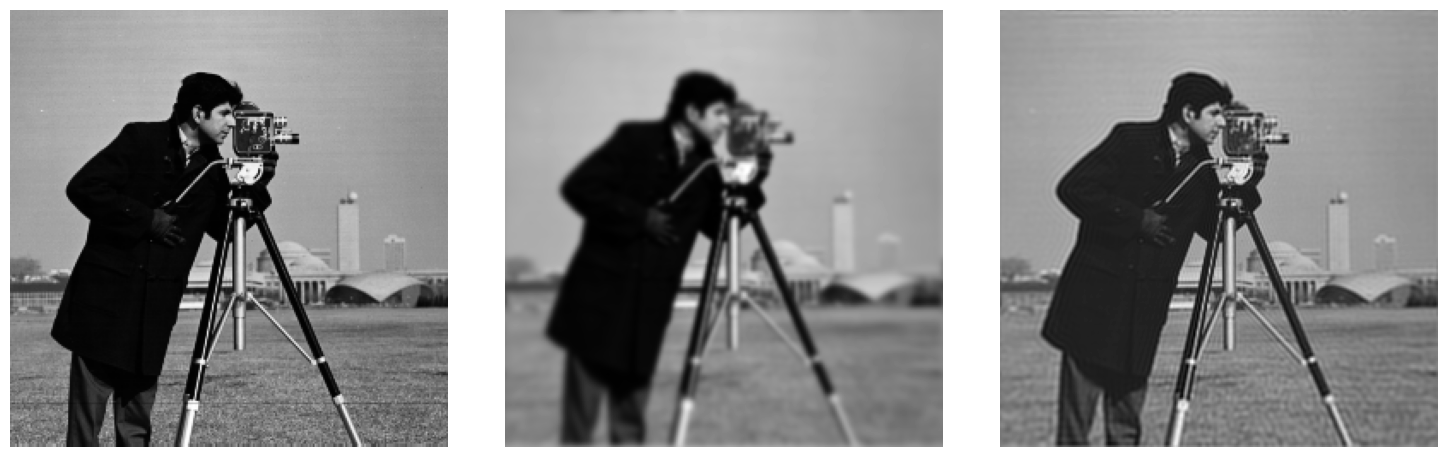

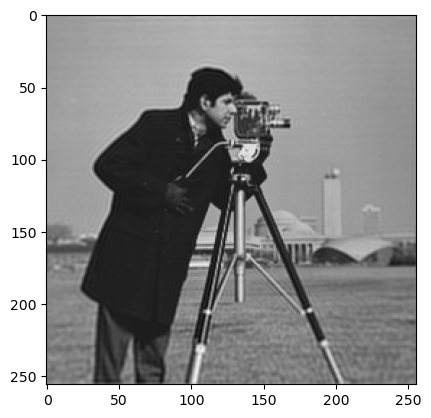

In [79]:
deblur_pars={'lamb':1e-8,'niter':256*256,'tol':5e-6}
deblur_rpca=blurtool.l2CGDeblur(blur_gt,deblur_pars,median_filter)

test_image_hat=deblur_rpca(blurred_test_image_gt,x_true=test_image,debug=True)

fig,ax=plt.subplots(1,3,figsize=(15,15))
plt.tight_layout()

print('-------------------------------------------')
print('SSIM(original,rpca_deblurred)=',blurtool.ssim(test_image,test_image_hat))
print('PSNR(original,rpca_deblurred)=',blurtool.psnr(test_image,test_image_hat))
print('-------------------------------------------')

ax[0].axis('off')
ax[0].imshow(test_image.cpu(),cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image_pca.cpu(),cmap='gray')
ax[1].axis('off')
ax[2].imshow(test_image_hat.cpu(),cmap='gray')
ax[2].axis('off')
plt.show()

plt.imshow(test_image_hat.cpu(),cmap='gray')

sub iteration:  0 	 rj_energy= 29.72468152716234
iter:  0 	 PSNR= 21.007832518758182
sub iteration:  1 	 rj_energy= 4.269714272076123
iter:  1 	 PSNR= 22.17019999523941
sub iteration:  2 	 rj_energy= 1.1912425544099756
iter:  2 	 PSNR= 22.64795471712415
sub iteration:  3 	 rj_energy= 0.477869673086375
iter:  3 	 PSNR= 22.975631975048373
sub iteration:  4 	 rj_energy= 0.22081204649681813
iter:  4 	 PSNR= 22.367036132052046
sub iteration:  5 	 rj_energy= 0.11930612760418831
iter:  5 	 PSNR= 22.434478494901654
sub iteration:  6 	 rj_energy= 0.0733451293059663
iter:  6 	 PSNR= 22.27859940065724
sub iteration:  7 	 rj_energy= 0.047869940063156584
iter:  7 	 PSNR= 21.82069001823752
sub iteration:  8 	 rj_energy= 0.03269659606569719
iter:  8 	 PSNR= 21.59713692551368
sub iteration:  9 	 rj_energy= 0.022158308348832
iter:  9 	 PSNR= 21.424416616402397
sub iteration:  10 	 rj_energy= 0.01647748896335773
iter:  10 	 PSNR= 21.258367586400983
sub iteration:  11 	 rj_energy= 0.012652885853213728
it

sub iteration:  91 	 rj_energy= 2.0260605328888075e-05
iter:  91 	 PSNR= 20.319661965991415
sub iteration:  92 	 rj_energy= 1.976122952994528e-05
iter:  92 	 PSNR= 20.30092043313126
sub iteration:  93 	 rj_energy= 1.918740807316521e-05
iter:  93 	 PSNR= 20.284065734433906
sub iteration:  94 	 rj_energy= 1.812266020174779e-05
iter:  94 	 PSNR= 20.269981631066074
sub iteration:  95 	 rj_energy= 1.757384361952389e-05
iter:  95 	 PSNR= 20.25442966142475
sub iteration:  96 	 rj_energy= 1.7210418460658075e-05
iter:  96 	 PSNR= 20.236992959803462
sub iteration:  97 	 rj_energy= 1.636302858123125e-05
iter:  97 	 PSNR= 20.22087886213275
sub iteration:  98 	 rj_energy= 1.588587682036044e-05
iter:  98 	 PSNR= 20.197553814562042
sub iteration:  99 	 rj_energy= 1.61768241758182e-05
iter:  99 	 PSNR= 20.176355297626444
sub iteration:  100 	 rj_energy= 1.556941327455888e-05
iter:  100 	 PSNR= 20.153604132583265
sub iteration:  101 	 rj_energy= 1.5248526403951738e-05
iter:  101 	 PSNR= 20.130736334844

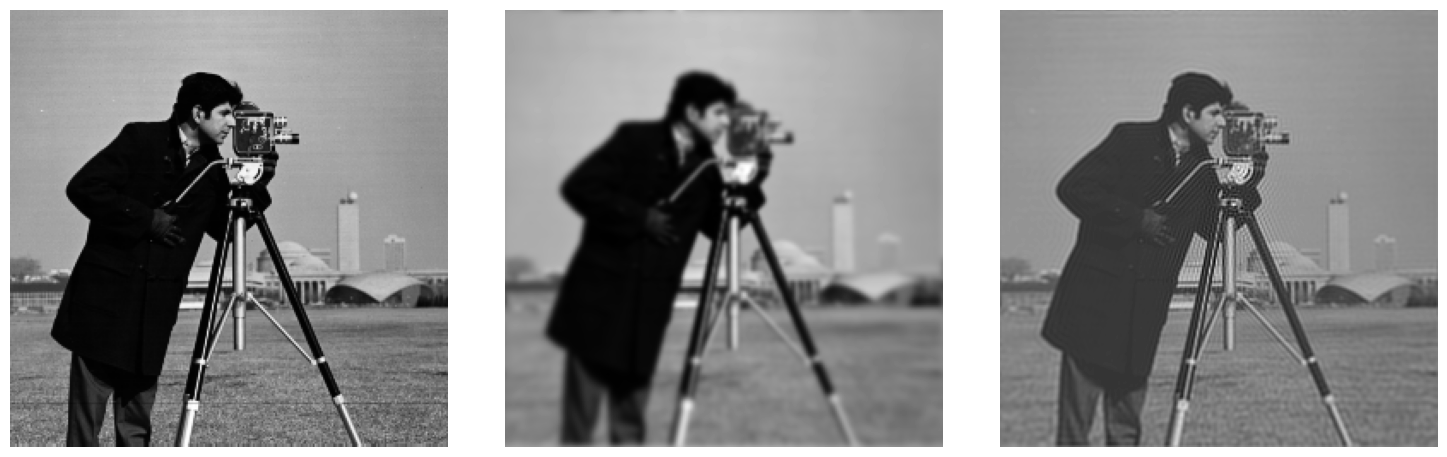

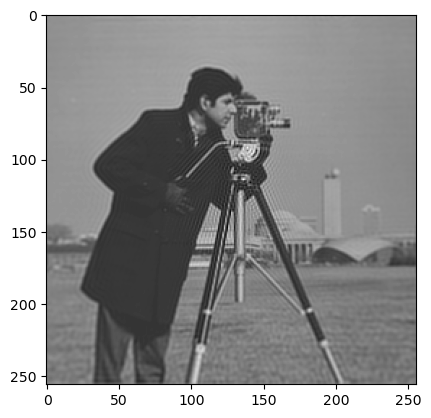

In [80]:
deblur_pars={'lamb':1e-8,'niter':256*256,'tol':5e-6}
deblur_rpca=blurtool.l2CGDeblur(rpca_blur,deblur_pars,median_filter)

test_image_hat=deblur_rpca(blurred_test_image_gt,x_true=test_image,debug=True)

fig,ax=plt.subplots(1,3,figsize=(15,15))
plt.tight_layout()

print('-------------------------------------------')
print('SSIM(original,rpca_deblurred)=',blurtool.ssim(test_image,test_image_hat))
print('PSNR(original,rpca_deblurred)=',blurtool.psnr(test_image,test_image_hat))
print('-------------------------------------------')

ax[0].axis('off')
ax[0].imshow(test_image.cpu(),cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image_pca.cpu(),cmap='gray')
ax[1].axis('off')
ax[2].imshow(test_image_hat.cpu(),cmap='gray')
ax[2].axis('off')
plt.show()

plt.imshow(test_image_hat.cpu(),cmap='gray')

sub iteration:  0 	 rj_energy= 151.72680469702337
iter:  0 	 PSNR= 14.683289262822202
sub iteration:  1 	 rj_energy= 62.47669240755055
iter:  1 	 PSNR= 18.11492500342476
sub iteration:  2 	 rj_energy= 21.037877311978537
iter:  2 	 PSNR= 17.47167111892341
sub iteration:  3 	 rj_energy= 9.151623027433754
iter:  3 	 PSNR= 16.901715094302084
sub iteration:  4 	 rj_energy= 5.219995189025422
iter:  4 	 PSNR= 16.119014448954996
sub iteration:  5 	 rj_energy= 2.5358386176079195
iter:  5 	 PSNR= 15.483056699718759
sub iteration:  6 	 rj_energy= 1.388443017728946
iter:  6 	 PSNR= 15.215688742464835
sub iteration:  7 	 rj_energy= 0.8360568389945022
iter:  7 	 PSNR= 14.909085637699613
sub iteration:  8 	 rj_energy= 0.48329675603141453
iter:  8 	 PSNR= 14.726156656388694
sub iteration:  9 	 rj_energy= 0.33336853167840313
iter:  9 	 PSNR= 14.601245768243631
sub iteration:  10 	 rj_energy= 0.22530818568848787
iter:  10 	 PSNR= 14.518118285377216
sub iteration:  11 	 rj_energy= 0.18355743701707822
ite

sub iteration:  92 	 rj_energy= 0.00020605872776919442
iter:  92 	 PSNR= 13.356324665413108
sub iteration:  93 	 rj_energy= 0.00019502585852847442
iter:  93 	 PSNR= 13.355519330411692
sub iteration:  94 	 rj_energy= 0.0002139692081765013
iter:  94 	 PSNR= 13.355106238282291
sub iteration:  95 	 rj_energy= 0.00020850327089089944
iter:  95 	 PSNR= 13.355256953987876
sub iteration:  96 	 rj_energy= 0.00020383823141228587
iter:  96 	 PSNR= 13.355242735773247
sub iteration:  97 	 rj_energy= 0.00019140375872320415
iter:  97 	 PSNR= 13.355696360290665
sub iteration:  98 	 rj_energy= 0.00019749889698110002
iter:  98 	 PSNR= 13.356181028047862
sub iteration:  99 	 rj_energy= 0.0001992960841841359
iter:  99 	 PSNR= 13.356595831217899
sub iteration:  100 	 rj_energy= 0.00019863387638577266
iter:  100 	 PSNR= 13.356222800661122
sub iteration:  101 	 rj_energy= 0.00020184970645866992
iter:  101 	 PSNR= 13.355695420726992
sub iteration:  102 	 rj_energy= 0.0002215180753016535
iter:  102 	 PSNR= 13.3

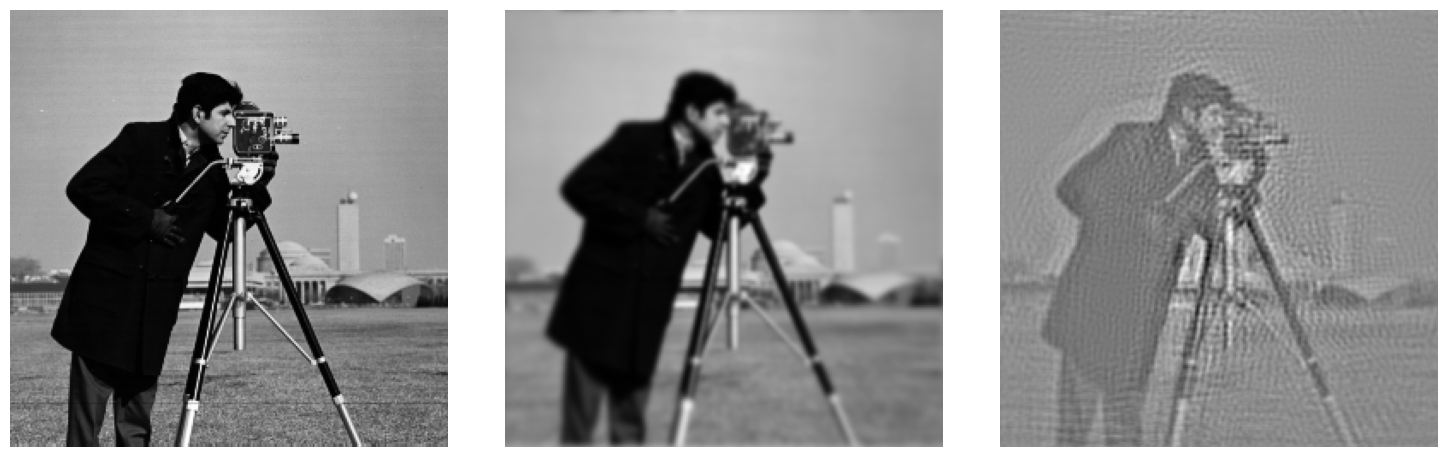

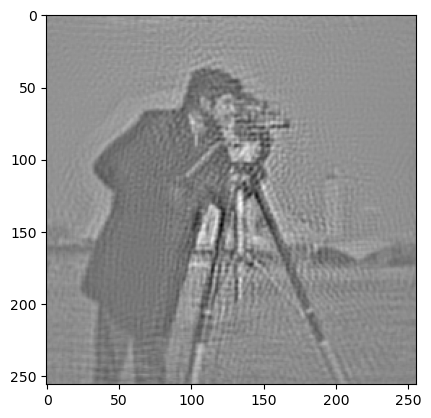

In [81]:
niter=163 # 256*256

deblur_pars={'lamb':1e-8,'niter':niter,'tol':5e-6}
deblur_rpca=blurtool.l2CGDeblur(pca_blur,deblur_pars,median_filter)

test_image_hat=deblur_rpca(blurred_test_image_gt,x_true=test_image,debug=True)

fig,ax=plt.subplots(1,3,figsize=(15,15))
plt.tight_layout()

print('-------------------------------------------')
print('SSIM(original,pca_deblurred)=',blurtool.ssim(test_image,test_image_hat))
print('PSNR(original,pca_deblurred)=',blurtool.psnr(test_image,test_image_hat))
print('-------------------------------------------')

ax[0].axis('off')
ax[0].imshow(test_image.cpu(),cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image_pca.cpu(),cmap='gray')
ax[1].axis('off')
ax[2].imshow(test_image_hat.cpu(),cmap='gray')
ax[2].axis('off')
plt.show()

plt.imshow(test_image_hat.cpu(),cmap='gray')

In [46]:
# x=test_image.clone().detach()
# psf_pars={'sx':0.01,'sy':0.01} # 0.008
# kernel=blurtool.Kernel(x.shape,mode='gaussian',psf_pars=psf_pars)
# bl=blurtool.StationaryBlur(kernel)
# y=bl.forward(x)
# y=blurtool.normalize_minmax(y)
# plt.imshow(y.cpu(),cmap='gray')
# plt.show()

# # median_filter=blurtool.MedianPool2d(kernel_size=3)
# # ffd_wrap= lambda xin:ffd(xin,0.01)

# deblur_pars={'niter':100,'mu':100,'lamb':0.0005}
# debl=blurtool.TVGDDeblur(bl,deblur_pars) #,median_filter)
# x_hat=debl.forward(y,x_true=x,debug=True)
# plt.imshow(x_hat.cpu(),cmap='gray')

In [ ]:
import

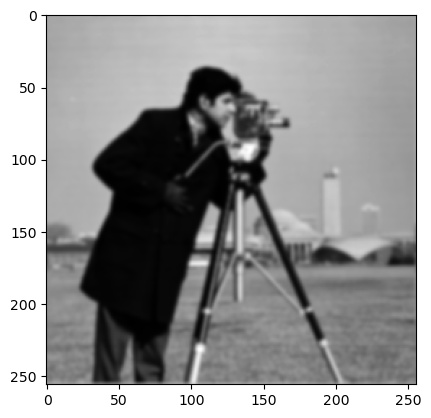

finnished  102  iterations of cg
iter:  0 	 PSNR= 25.013947853960236


KeyboardInterrupt: 

In [303]:
x=test_image.clone().detach()
psf_pars={'sx':0.01,'sy':0.01}
kernel=blurtool.Kernel(x.shape,mode='gaussian',psf_pars=psf_pars)
bl=blurtool.StationaryBlur(kernel)
y=bl.forward(x)
y=blurtool.normalize_minmax(y)
plt.imshow(y.cpu(),cmap='gray')
plt.show()

median_filter=blurtool.MedianPool2d(kernel_size=3)
ffd_wrap= lambda xin: blurtool.ffd(xin,0.05)

deblur_pars={'niter':100,'mu':1e-3,'cg_tol':1e-8} # 1e-15
debl=blurtool.PnPADMMDeblur(bl,deblur_pars,ffd_wrap)
x_hat=debl.forward(y,x_true=x,debug=True)
plt.imshow(x_hat.cpu(),cmap='gray')

In [14]:
print('oi')

oi


finnished  24878  iterations of cg
iter:  0 	 PSNR= 27.38735719135231
finnished  22477  iterations of cg
iter:  1 	 PSNR= 30.375902883928912
finnished  18024  iterations of cg
iter:  2 	 PSNR= 30.290545580464464
--------------------------
mu= 1e-08 	 gamma= 1


NameError: name 'blurred_test_image' is not defined

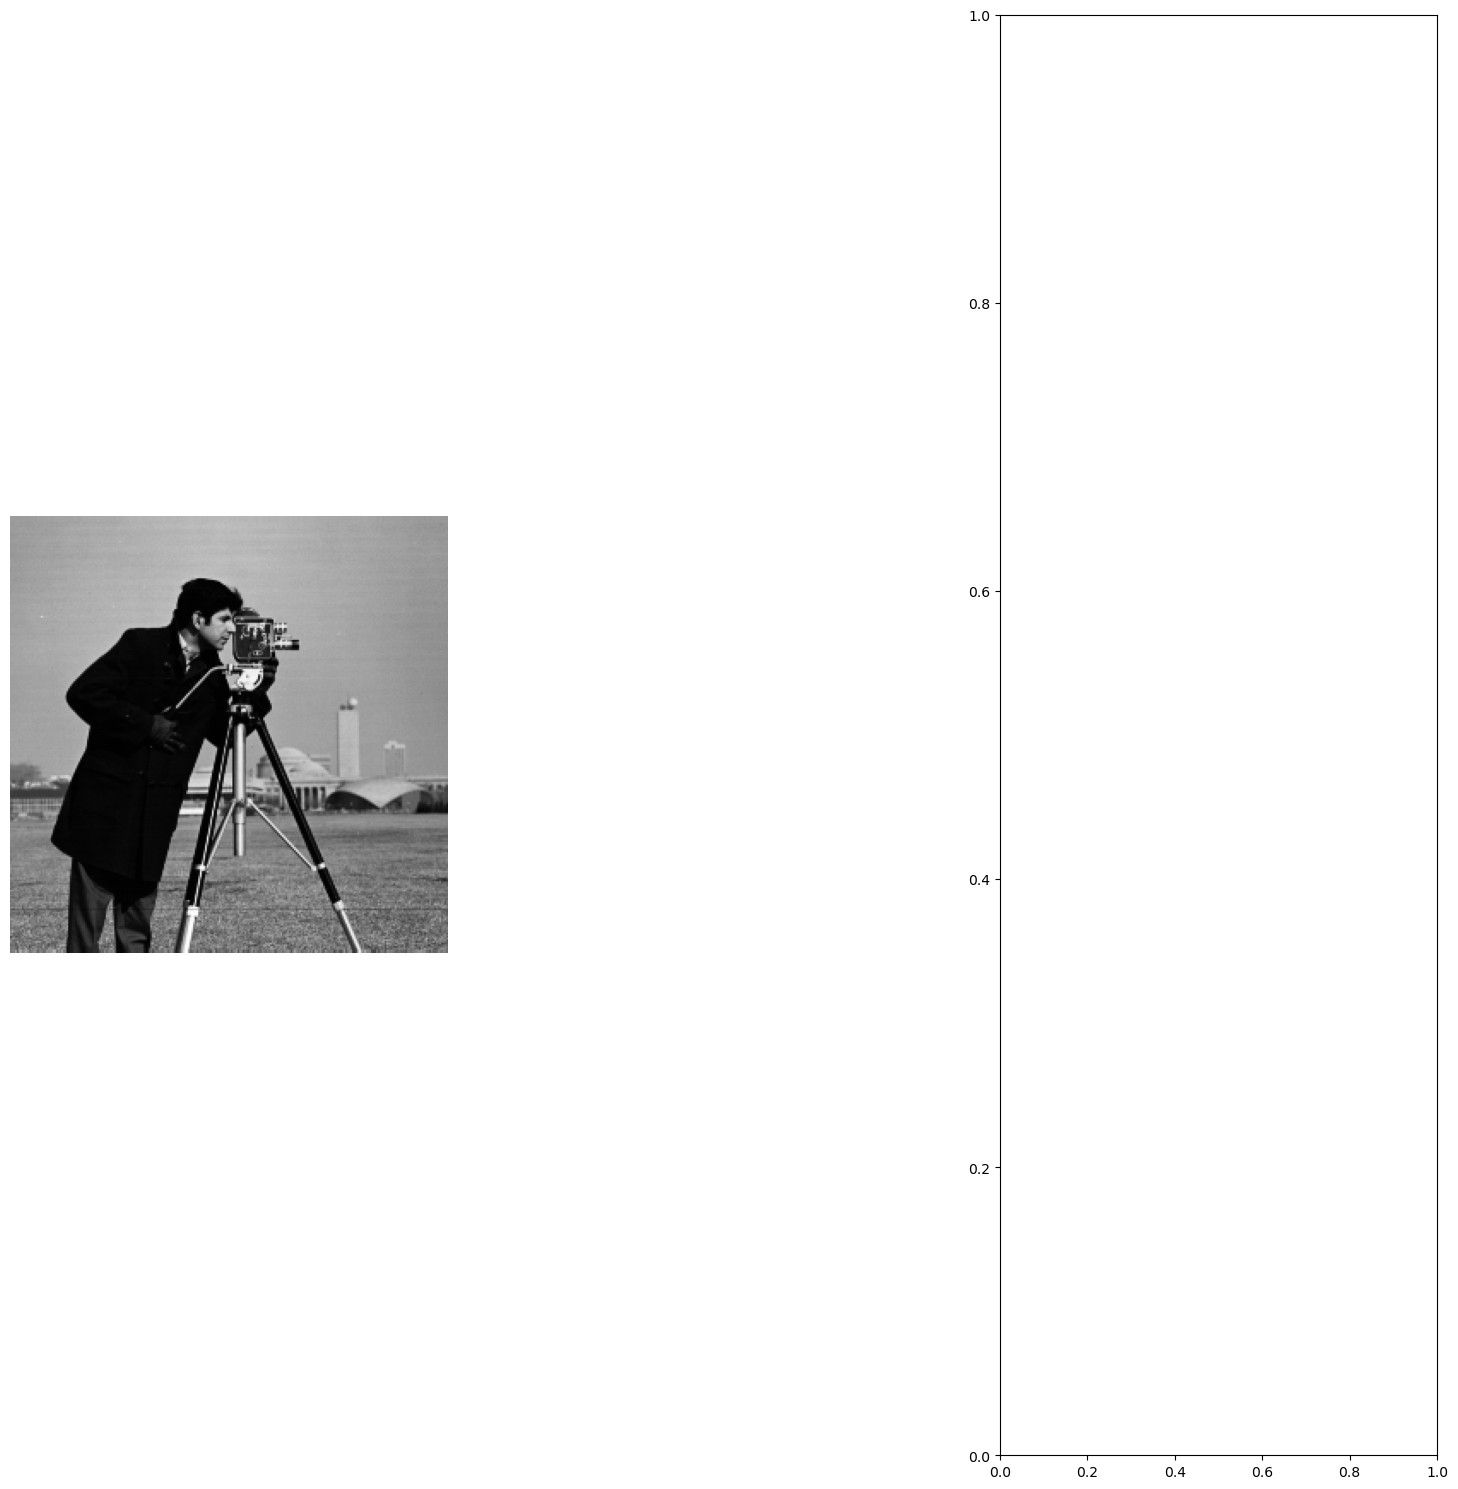

In [20]:
for niter in [3,10]:
    for gamma in [1,0.1]:
        for mu in [1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1e0,1e1]:
            deblur_pars={'niter':niter,'mu':mu,'cg_niter':256*256,'cg_tol':1e-15,'gamma':1}
            median_filter=blurtool.MedianPool2d(kernel_size=3)
            ffd_wrap= lambda xin:blurtool.ffd(xin,0.008)
            deblur_rpca=blurtool.PnPADMMDeblur(blur_pca,deblur_pars,ffd_wrap,mode='cg')

            test_image_hat=deblur_rpca(blurred_test_image_pca,x_true=test_image,debug=True)

            print('--------------------------')
            print('mu=',mu,'\t gamma=',gamma)

            fig,ax=plt.subplots(1,3,figsize=(15,15))
            plt.tight_layout()

            ax[0].axis('off')
            ax[0].imshow(test_image.cpu(),cmap='gray')
            ax[1].axis('off')
            ax[1].imshow(blurred_test_image_oca.cpu(),cmap='gray')
            ax[1].axis('off')
            ax[2].imshow(test_image_hat.cpu(),cmap='gray')
            ax[2].axis('off')
            plt.show()

            plt.imshow(test_image_hat.cpu(),cmap='gray')

            print('--------------------------')

In [ ]:
for niter in [3,10]:
    for gamma in [1,0.1]:
        for mu in [1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1e0,1e1]:
            deblur_pars={'niter':niter,'mu':mu,'cg_niter':256*256,'cg_tol':1e-15,'gamma':1}
            median_filter=blurtool.MedianPool2d(kernel_size=3)
            ffd_wrap= lambda xin:blurtool.ffd(xin,0.008)
            deblur_rpca=blurtool.PnPADMMDeblur(rpca_blur,deblur_pars,ffd_wrap,mode='cg')

            test_image_hat=deblur_rpca(blurred_test_image_pca,x_true=test_image,debug=True)

            print('--------------------------')
            print('mu=',mu,'\t gamma=',gamma)

            fig,ax=plt.subplots(1,3,figsize=(15,15))
            plt.tight_layout()

            ax[0].axis('off')
            ax[0].imshow(test_image.cpu(),cmap='gray')
            ax[1].axis('off')
            ax[1].imshow(blurred_test_image.cpu(),cmap='gray')
            ax[1].axis('off')
            ax[2].imshow(test_image_hat.cpu(),cmap='gray')
            ax[2].axis('off')
            plt.show()

            plt.imshow(test_image_hat.cpu(),cmap='gray')

            print('--------------------------')

NameError: name 'blurred_test_image_oca' is not defined

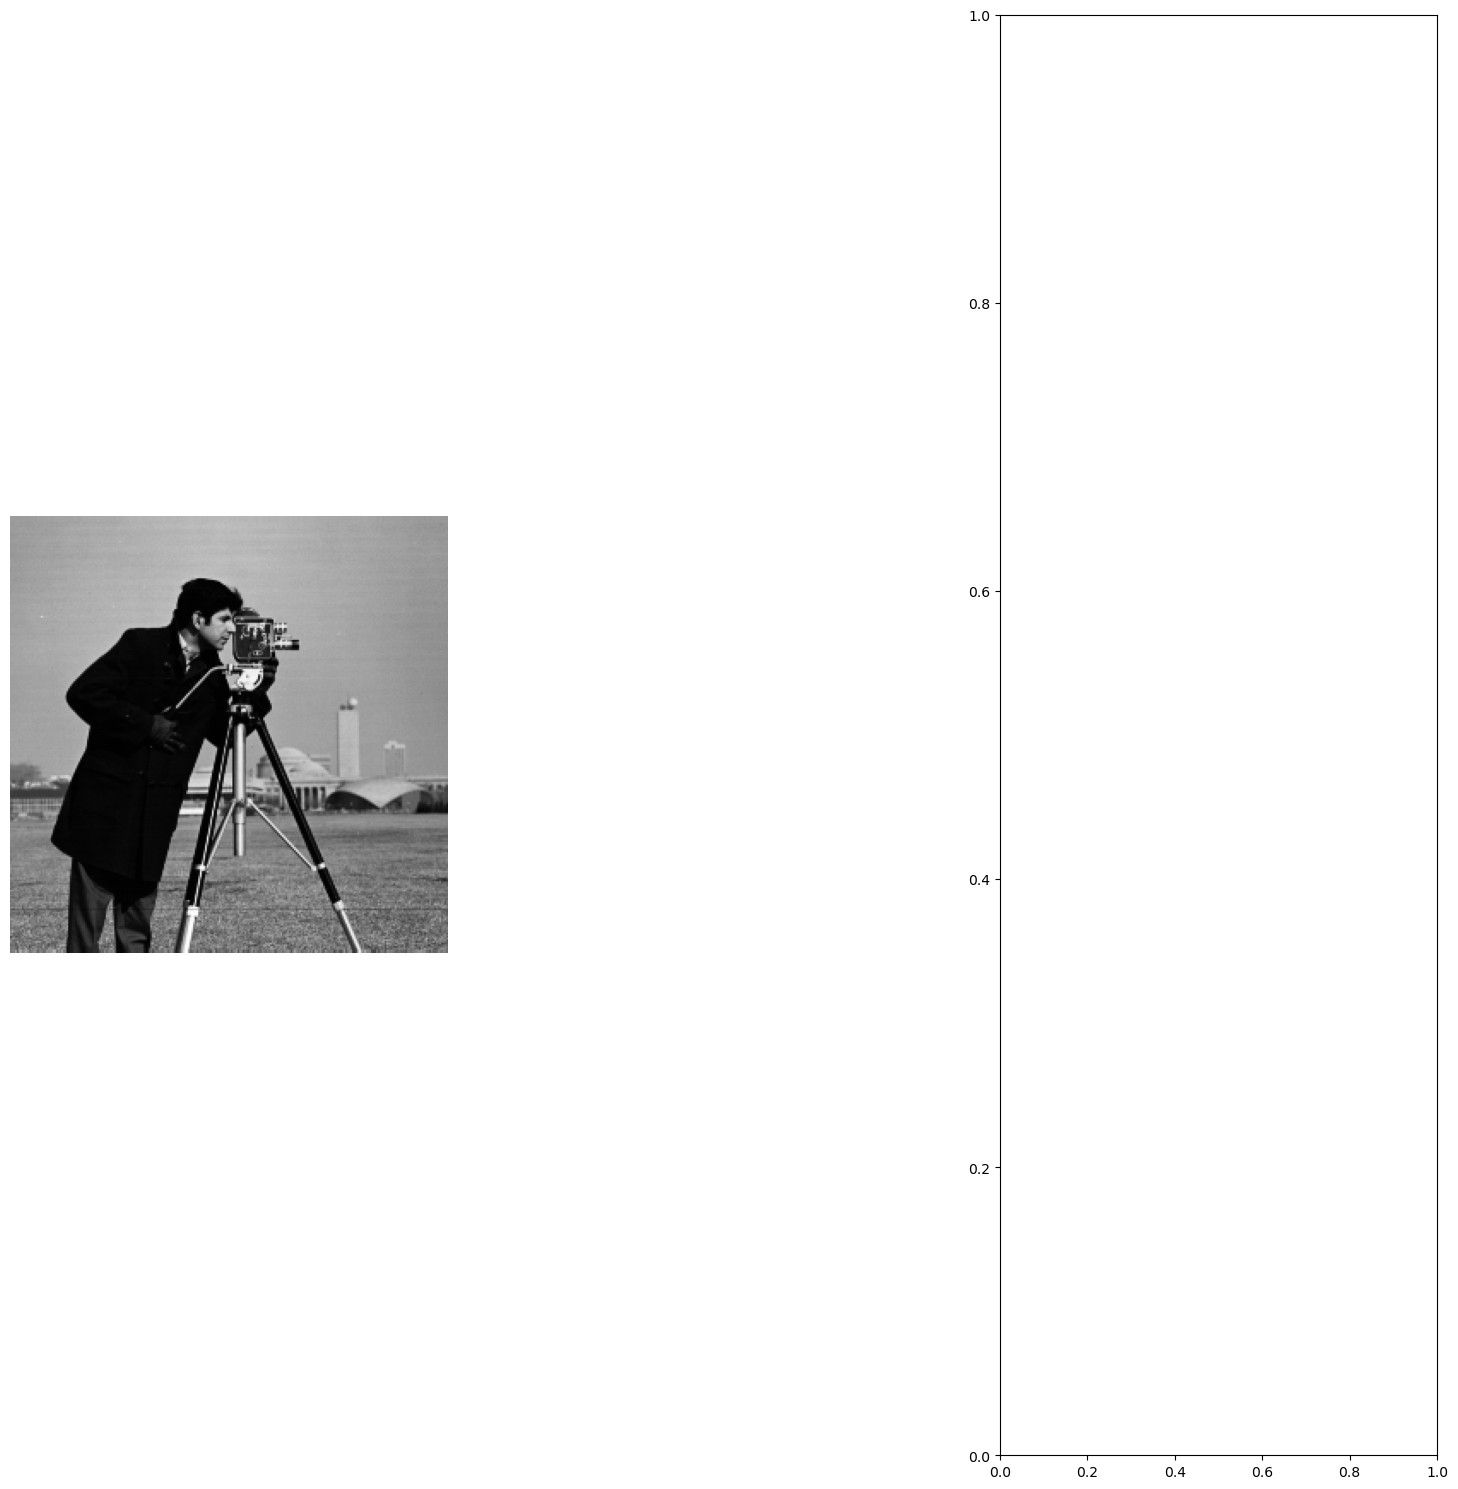

In [21]:
            fig,ax=plt.subplots(1,3,figsize=(15,15))
            plt.tight_layout()

            ax[0].axis('off')
            ax[0].imshow(test_image.cpu(),cmap='gray')
            ax[1].axis('off')
            ax[1].imshow(blurred_test_image_oca.cpu(),cmap='gray')
            ax[1].axis('off')
            ax[2].imshow(test_image_hat.cpu(),cmap='gray')
            ax[2].axis('off')
            plt.show()

In [74]:
test_image.shape

torch.Size([256, 256])

did row  0
did row  1
did row  2
did row  3
did row  4
did row  5
did row  6
did row  7
did row  8
did row  9
did row  10
did row  11
did row  12
did row  13
did row  14
did row  15
did row  16
did row  17
did row  18
did row  19
did row  20
did row  21
did row  22
did row  23
did row  24
did row  25
did row  26
did row  27
did row  28
did row  29
did row  30
did row  31
did row  32
did row  33
did row  34
did row  35
did row  36
did row  37
did row  38
did row  39
did row  40
did row  41
did row  42
did row  43
did row  44
did row  45
did row  46
did row  47
did row  48
did row  49
did row  50
did row  51
did row  52
did row  53
did row  54
did row  55
did row  56
did row  57
did row  58
did row  59
did row  60
did row  61
did row  62
did row  63
did row  64
did row  65
did row  66
did row  67
did row  68
did row  69
did row  70
did row  71
did row  72
did row  73
did row  74
did row  75
did row  76
did row  77
did row  78
did row  79
did row  80
did row  81
did row  82
did row  83
di

did row  640
did row  641
did row  642
did row  643
did row  644
did row  645
did row  646
did row  647
did row  648
did row  649
did row  650
did row  651
did row  652
did row  653
did row  654
did row  655
did row  656
did row  657
did row  658
did row  659
did row  660
did row  661
did row  662
did row  663
did row  664
did row  665
did row  666
did row  667
did row  668
did row  669
did row  670
did row  671
did row  672
did row  673
did row  674
did row  675
did row  676
did row  677
did row  678
did row  679
did row  680
did row  681
did row  682
did row  683
did row  684
did row  685
did row  686
did row  687
did row  688
did row  689
did row  690
did row  691
did row  692
did row  693
did row  694
did row  695
did row  696
did row  697
did row  698
did row  699
did row  700
did row  701
did row  702
did row  703
did row  704
did row  705
did row  706
did row  707
did row  708
did row  709
did row  710
did row  711
did row  712
did row  713
did row  714
did row  715
did row  716

did row  1252
did row  1253
did row  1254
did row  1255
did row  1256
did row  1257
did row  1258
did row  1259
did row  1260
did row  1261
did row  1262
did row  1263
did row  1264
did row  1265
did row  1266
did row  1267
did row  1268
did row  1269
did row  1270
did row  1271
did row  1272
did row  1273
did row  1274
did row  1275
did row  1276
did row  1277
did row  1278
did row  1279
did row  1280
did row  1281
did row  1282
did row  1283
did row  1284
did row  1285
did row  1286
did row  1287
did row  1288
did row  1289
did row  1290
did row  1291
did row  1292
did row  1293
did row  1294
did row  1295
did row  1296
did row  1297
did row  1298
did row  1299
did row  1300
did row  1301
did row  1302
did row  1303
did row  1304
did row  1305
did row  1306
did row  1307
did row  1308
did row  1309
did row  1310
did row  1311
did row  1312
did row  1313
did row  1314
did row  1315
did row  1316
did row  1317
did row  1318
did row  1319
did row  1320
did row  1321
did row  1322
did ro

did row  1838
did row  1839
did row  1840
did row  1841
did row  1842
did row  1843
did row  1844
did row  1845
did row  1846
did row  1847
did row  1848
did row  1849
did row  1850
did row  1851
did row  1852
did row  1853
did row  1854
did row  1855
did row  1856
did row  1857
did row  1858
did row  1859
did row  1860
did row  1861
did row  1862
did row  1863
did row  1864
did row  1865
did row  1866
did row  1867
did row  1868
did row  1869
did row  1870
did row  1871
did row  1872
did row  1873
did row  1874
did row  1875
did row  1876
did row  1877
did row  1878
did row  1879
did row  1880
did row  1881
did row  1882
did row  1883
did row  1884
did row  1885
did row  1886
did row  1887
did row  1888
did row  1889
did row  1890
did row  1891
did row  1892
did row  1893
did row  1894
did row  1895
did row  1896
did row  1897
did row  1898
did row  1899
did row  1900
did row  1901
did row  1902
did row  1903
did row  1904
did row  1905
did row  1906
did row  1907
did row  1908
did ro

did row  2424
did row  2425
did row  2426
did row  2427
did row  2428
did row  2429
did row  2430
did row  2431
did row  2432
did row  2433
did row  2434
did row  2435
did row  2436
did row  2437
did row  2438
did row  2439
did row  2440
did row  2441
did row  2442
did row  2443
did row  2444
did row  2445
did row  2446
did row  2447
did row  2448
did row  2449
did row  2450
did row  2451
did row  2452
did row  2453
did row  2454
did row  2455
did row  2456
did row  2457
did row  2458
did row  2459
did row  2460
did row  2461
did row  2462
did row  2463
did row  2464
did row  2465
did row  2466
did row  2467
did row  2468
did row  2469
did row  2470
did row  2471
did row  2472
did row  2473
did row  2474
did row  2475
did row  2476
did row  2477
did row  2478
did row  2479
did row  2480
did row  2481
did row  2482
did row  2483
did row  2484
did row  2485
did row  2486
did row  2487
did row  2488
did row  2489
did row  2490
did row  2491
did row  2492
did row  2493
did row  2494
did ro

...

did row  63196
did row  63197
did row  63198
did row  63199
did row  63200
did row  63201
did row  63202
did row  63203
did row  63204
did row  63205
did row  63206
did row  63207
did row  63208
did row  63209
did row  63210
did row  63211
did row  63212
did row  63213
did row  63214
did row  63215
did row  63216
did row  63217
did row  63218
did row  63219
did row  63220
did row  63221
did row  63222
did row  63223
did row  63224
did row  63225
did row  63226
did row  63227
did row  63228
did row  63229
did row  63230
did row  63231
did row  63232
did row  63233
did row  63234
did row  63235
did row  63236
did row  63237
did row  63238
did row  63239
did row  63240
did row  63241
did row  63242
did row  63243
did row  63244
did row  63245
did row  63246
did row  63247
did row  63248
did row  63249
did row  63250
did row  63251
did row  63252
did row  63253
did row  63254
did row  63255
did row  63256
did row  63257
did row  63258
did row  63259
did row  63260
did row  63261
did row  6

did row  63744
did row  63745
did row  63746
did row  63747
did row  63748
did row  63749
did row  63750
did row  63751
did row  63752
did row  63753
did row  63754
did row  63755
did row  63756
did row  63757
did row  63758
did row  63759
did row  63760
did row  63761
did row  63762
did row  63763
did row  63764
did row  63765
did row  63766
did row  63767
did row  63768
did row  63769
did row  63770
did row  63771
did row  63772
did row  63773
did row  63774
did row  63775
did row  63776
did row  63777
did row  63778
did row  63779
did row  63780
did row  63781
did row  63782
did row  63783
did row  63784
did row  63785
did row  63786
did row  63787
did row  63788
did row  63789
did row  63790
did row  63791
did row  63792
did row  63793
did row  63794
did row  63795
did row  63796
did row  63797
did row  63798
did row  63799
did row  63800
did row  63801
did row  63802
did row  63803
did row  63804
did row  63805
did row  63806
did row  63807
did row  63808
did row  63809
did row  6

did row  64292
did row  64293
did row  64294
did row  64295
did row  64296
did row  64297
did row  64298
did row  64299
did row  64300
did row  64301
did row  64302
did row  64303
did row  64304
did row  64305
did row  64306
did row  64307
did row  64308
did row  64309
did row  64310
did row  64311
did row  64312
did row  64313
did row  64314
did row  64315
did row  64316
did row  64317
did row  64318
did row  64319
did row  64320
did row  64321
did row  64322
did row  64323
did row  64324
did row  64325
did row  64326
did row  64327
did row  64328
did row  64329
did row  64330
did row  64331
did row  64332
did row  64333
did row  64334
did row  64335
did row  64336
did row  64337
did row  64338
did row  64339
did row  64340
did row  64341
did row  64342
did row  64343
did row  64344
did row  64345
did row  64346
did row  64347
did row  64348
did row  64349
did row  64350
did row  64351
did row  64352
did row  64353
did row  64354
did row  64355
did row  64356
did row  64357
did row  6

did row  64840
did row  64841
did row  64842
did row  64843
did row  64844
did row  64845
did row  64846
did row  64847
did row  64848
did row  64849
did row  64850
did row  64851
did row  64852
did row  64853
did row  64854
did row  64855
did row  64856
did row  64857
did row  64858
did row  64859
did row  64860
did row  64861
did row  64862
did row  64863
did row  64864
did row  64865
did row  64866
did row  64867
did row  64868
did row  64869
did row  64870
did row  64871
did row  64872
did row  64873
did row  64874
did row  64875
did row  64876
did row  64877
did row  64878
did row  64879
did row  64880
did row  64881
did row  64882
did row  64883
did row  64884
did row  64885
did row  64886
did row  64887
did row  64888
did row  64889
did row  64890
did row  64891
did row  64892
did row  64893
did row  64894
did row  64895
did row  64896
did row  64897
did row  64898
did row  64899
did row  64900
did row  64901
did row  64902
did row  64903
did row  64904
did row  64905
did row  6

did row  65388
did row  65389
did row  65390
did row  65391
did row  65392
did row  65393
did row  65394
did row  65395
did row  65396
did row  65397
did row  65398
did row  65399
did row  65400
did row  65401
did row  65402
did row  65403
did row  65404
did row  65405
did row  65406
did row  65407
did row  65408
did row  65409
did row  65410
did row  65411
did row  65412
did row  65413
did row  65414
did row  65415
did row  65416
did row  65417
did row  65418
did row  65419
did row  65420
did row  65421
did row  65422
did row  65423
did row  65424
did row  65425
did row  65426
did row  65427
did row  65428
did row  65429
did row  65430
did row  65431
did row  65432
did row  65433
did row  65434
did row  65435
did row  65436
did row  65437
did row  65438
did row  65439
did row  65440
did row  65441
did row  65442
did row  65443
did row  65444
did row  65445
did row  65446
did row  65447
did row  65448
did row  65449
did row  65450
did row  65451
did row  65452
did row  65453
did row  6

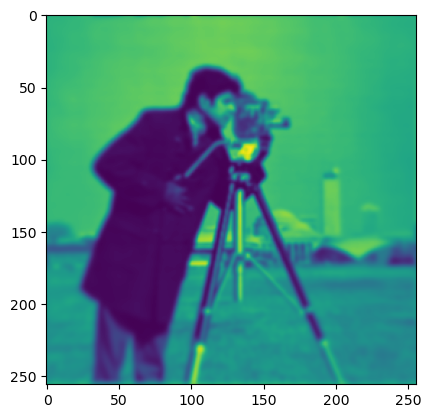

In [77]:
A=torch.zeros(256*256,256*256)
for i in range(256*256):
    ei=torch.zeros(test_image.shape[0]*test_image.shape[1]).to(device)
    ei[i]=1
    Aei=blur_pca(ei.reshape(256,256))
    A[:,i]=Aei.reshape(256*256)
    print('did row ',i)
    


In [78]:
plt.imshow(A.dot(test_image.reshape(256*256)).reshape(256,256))

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument tensor in method wrapper_CUDA__dot)

In [ ]:
print(torch.linalg.cond(A))

In [1]:
print('oi')

oi


In [2]:
A

NameError: name 'A' is not defined